In [93]:
using JLD2
using Printf
using Plots


In [ ]:


function load_data(directory::String=joinpath(@__DIR__, "data_EPS"))
    # Keys will be the cutoff (Float64), and values will be the data dictionaries.
    all_data = Dict{Float64, Dict{String, Any}}()
    
    # We loop from 4 to 16, just like the HPC array
    powers = 4:16
    
    for p in powers
        cutoff_val = 10.0^(-p)
        cutoff_str = @sprintf("%.0e", cutoff_val)
        filename = joinpath(directory, "data_$(cutoff_str).jld2")
        
        if isfile(filename)
            println("Loading: $filename")
            # `load` automatically reads the JLD2 file into a Dict{String, Any}
            data = load(filename)
            all_data[cutoff_val] = data
        else
            @warn "File not found, skipping: $filename"
        end
    end
    
    return all_data
end



load_data (generic function with 2 methods)

In [95]:

data_dict = load_data(joinpath(@__DIR__, "data"))

println("\nSuccessfully loaded data for $(length(data_dict)) cutoffs.")

# 2. How to access specific data
# Let's say we want to look at the data for the 1e-16 cutoff
target_cutoff = 1e-16

if haskey(data_dict, target_cutoff)
    println("\n--- Extracting variables for EPS = $target_cutoff ---")
    
    target_data = data_dict[target_cutoff]
    
    # Extracting the arrays exactly as you requested
    avg_matrix   = target_data["avg_matrix"]     # Average bond dimensions
    err_matrix   = target_data["err_matrix"]     # Standard deviations
    N_range      = target_data["N_range"]        # System sizes (x-axis)
    sigma_values = target_data["sigma_values"]   # Disorder strengths
    vn_avg       = target_data["vn_avg"]         # Von Neumann entropy
    s05_avg      = target_data["s05_avg"]        # Renyi alpha = 0.5
    s0_avg       = target_data["s0_avg"]         # Renyi alpha = 0
    spectra_avg  = target_data["spectra_avg"]    # 3D Schmidt spectrum
    
    println("N_range: ", N_range)
    println("sigma_values: ", sigma_values)
    println("Size of avg_matrix: ", size(avg_matrix))
    println("Size of spectra_avg: ", size(spectra_avg))
    
    # Example: Get the average bond dimension for the 3rd N value and 2nd sigma value
    example_bd = avg_matrix[3, 2]
    println("\nExample: Average Bond Dimension at N=$(N_range[3]), sigma=$(sigma_values[2]) is $example_bd")
end

Loading: c:\Users\Ethan\OneDrive - University of Bristol\Labs\Y4 Labs\A_Ethan_code\A_Sigmas\data\data_1e-04.jld2


Loading: c:\Users\Ethan\OneDrive - University of Bristol\Labs\Y4 Labs\A_Ethan_code\A_Sigmas\data\data_1e-05.jld2
Loading: c:\Users\Ethan\OneDrive - University of Bristol\Labs\Y4 Labs\A_Ethan_code\A_Sigmas\data\data_1e-06.jld2
Loading: c:\Users\Ethan\OneDrive - University of Bristol\Labs\Y4 Labs\A_Ethan_code\A_Sigmas\data\data_1e-07.jld2
Loading: c:\Users\Ethan\OneDrive - University of Bristol\Labs\Y4 Labs\A_Ethan_code\A_Sigmas\data\data_1e-08.jld2
Loading: c:\Users\Ethan\OneDrive - University of Bristol\Labs\Y4 Labs\A_Ethan_code\A_Sigmas\data\data_1e-09.jld2
Loading: c:\Users\Ethan\OneDrive - University of Bristol\Labs\Y4 Labs\A_Ethan_code\A_Sigmas\data\data_1e-10.jld2
Loading: c:\Users\Ethan\OneDrive - University of Bristol\Labs\Y4 Labs\A_Ethan_code\A_Sigmas\data\data_1e-11.jld2
Loading: c:\Users\Ethan\OneDrive - University of Bristol\Labs\Y4 Labs\A_Ethan_code\A_Sigmas\data\data_1e-12.jld2
Loading: c:\Users\Ethan\OneDrive - University of Bristol\Labs\Y4 Labs\A_Ethan_code\A_Sigmas\dat

In [96]:
function plot_bond_dimensions(data_dict; selected_sigmas=nothing, selected_cutoffs=nothing, selected_N=nothing, plot_errors=false)
    plt_array = []
    
    all_cutoffs = sort(collect(keys(data_dict)), rev=true)
    
    cutoffs = if selected_cutoffs !== nothing
        filter(c -> c in selected_cutoffs, all_cutoffs)
    else
        all_cutoffs
    end
    
    if isempty(cutoffs)
        @warn "No valid cutoffs found/selected to plot."
        return plot() 
    end
    
    for cutoff in cutoffs
        target_data  = data_dict[cutoff]
        avg_matrix   = target_data["avg_matrix"]
        err_matrix   = target_data["err_matrix"]
        N_range      = target_data["N_range"]
        sigma_values = target_data["sigma_values"]
        
        N_idx = if selected_N !== nothing
            findall(n -> n in selected_N, N_range)
        else
            1:length(N_range)
        end
        
        p = plot(
            title="EPS = $cutoff", 
            xlabel="System Size N", 
            ylabel="Bond Dimension",
            legend=:topleft
        )
        
        for (j, sig) in enumerate(sigma_values)
            if selected_sigmas !== nothing && !(sig in selected_sigmas)
                continue
            end
            
            if plot_errors && sig != 0.0
                plot!(p, N_range[N_idx], avg_matrix[N_idx, j], yerror=err_matrix[N_idx, j], label="σ = $sig")
            else
                plot!(p, N_range[N_idx], avg_matrix[N_idx, j], label="σ = $sig")
            end
        end
        
        push!(plt_array, p)
    end
    
    n_plots = length(plt_array)
    
    cols = min(4, n_plots)
    rows = ceil(Int, n_plots / cols)
    
    final_plot = plot(
        plt_array..., 
        layout=(rows, cols), 
        size=(400 * cols, 350 * rows),
        plot_title="Bond Dimension vs System Size Across Truncations",
        margin=5Plots.mm
    )
    
    return final_plot
end

plot_bond_dimensions (generic function with 1 method)

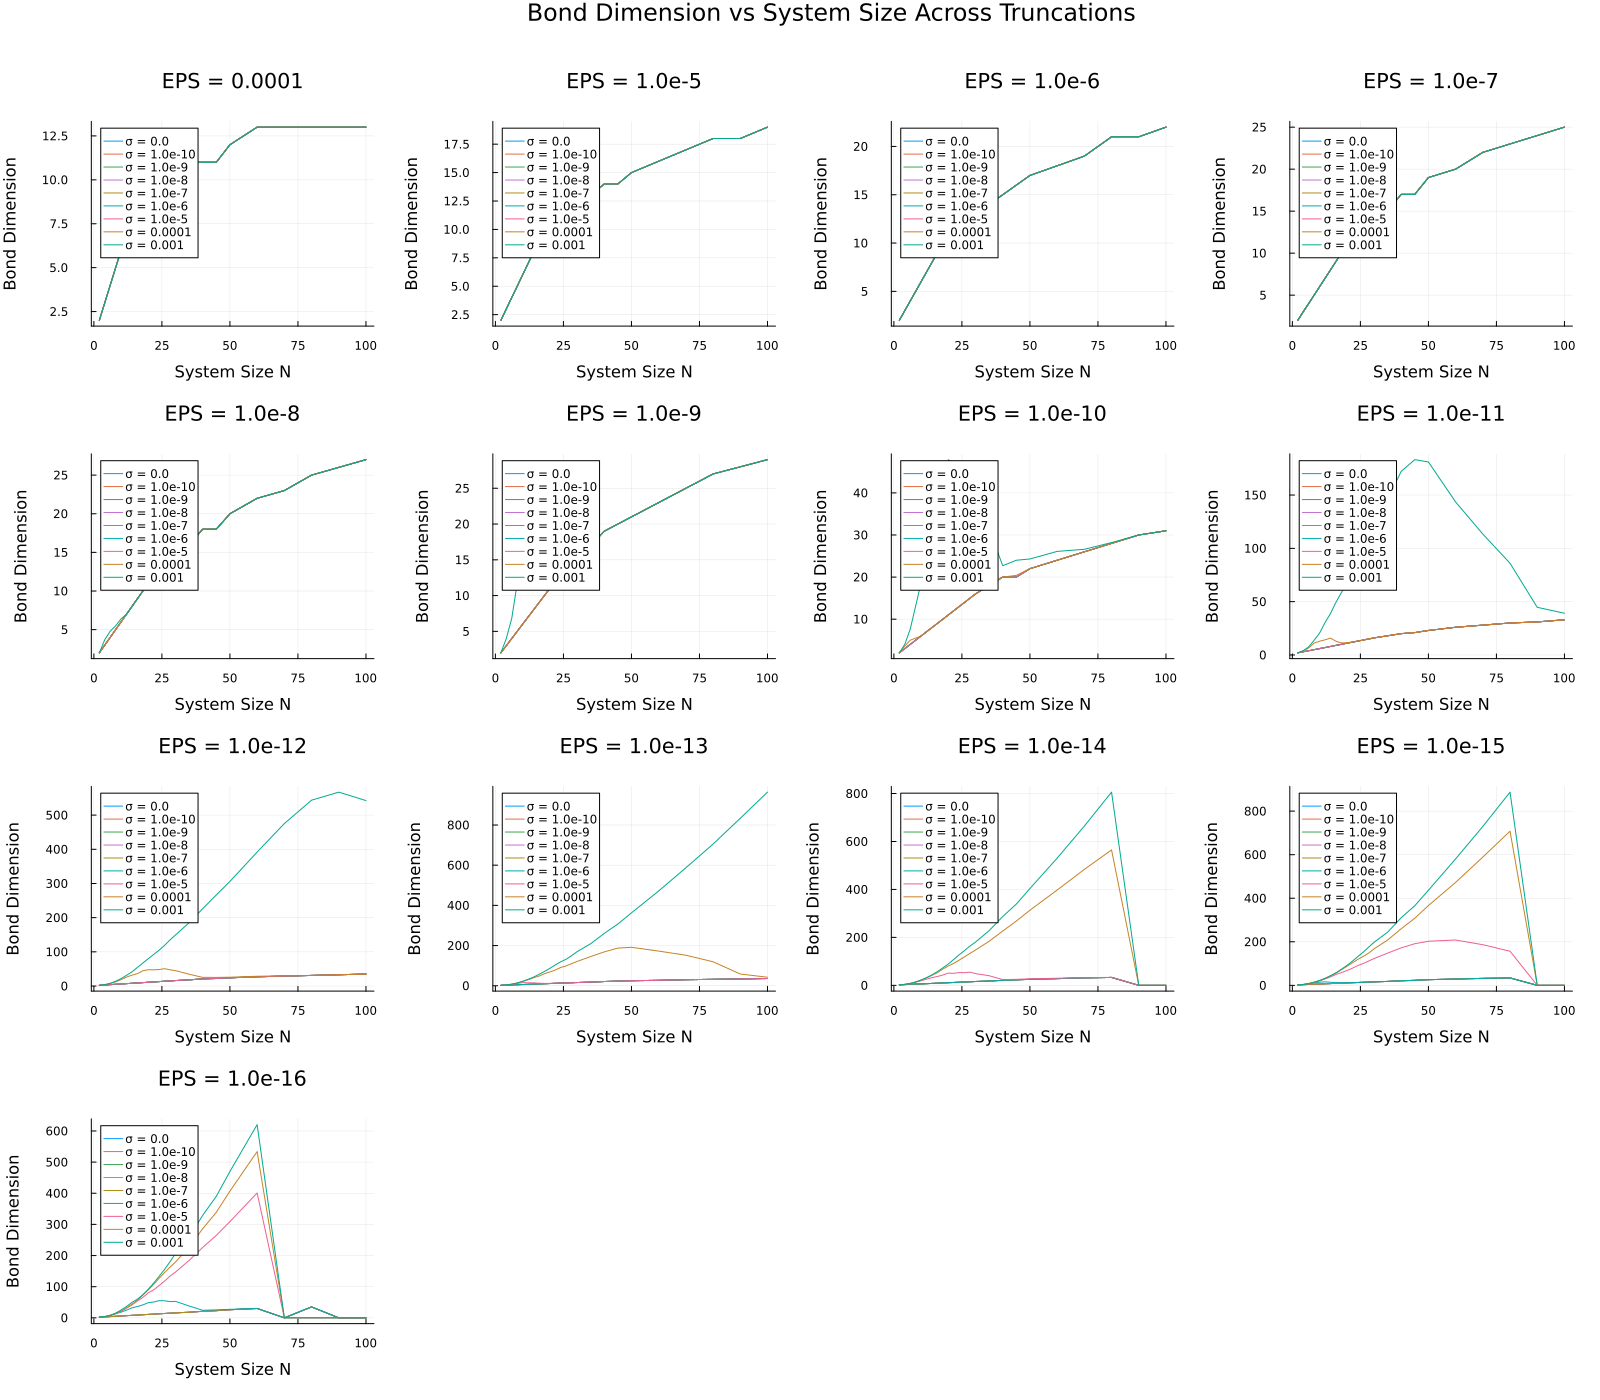

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Sigmas\\images\\bd_grid_all.png"

In [ ]:

p = plot_bond_dimensions(data_dict)
display(p)
savefig(p, joinpath("images_EPS", "bd_grid_all.png"))

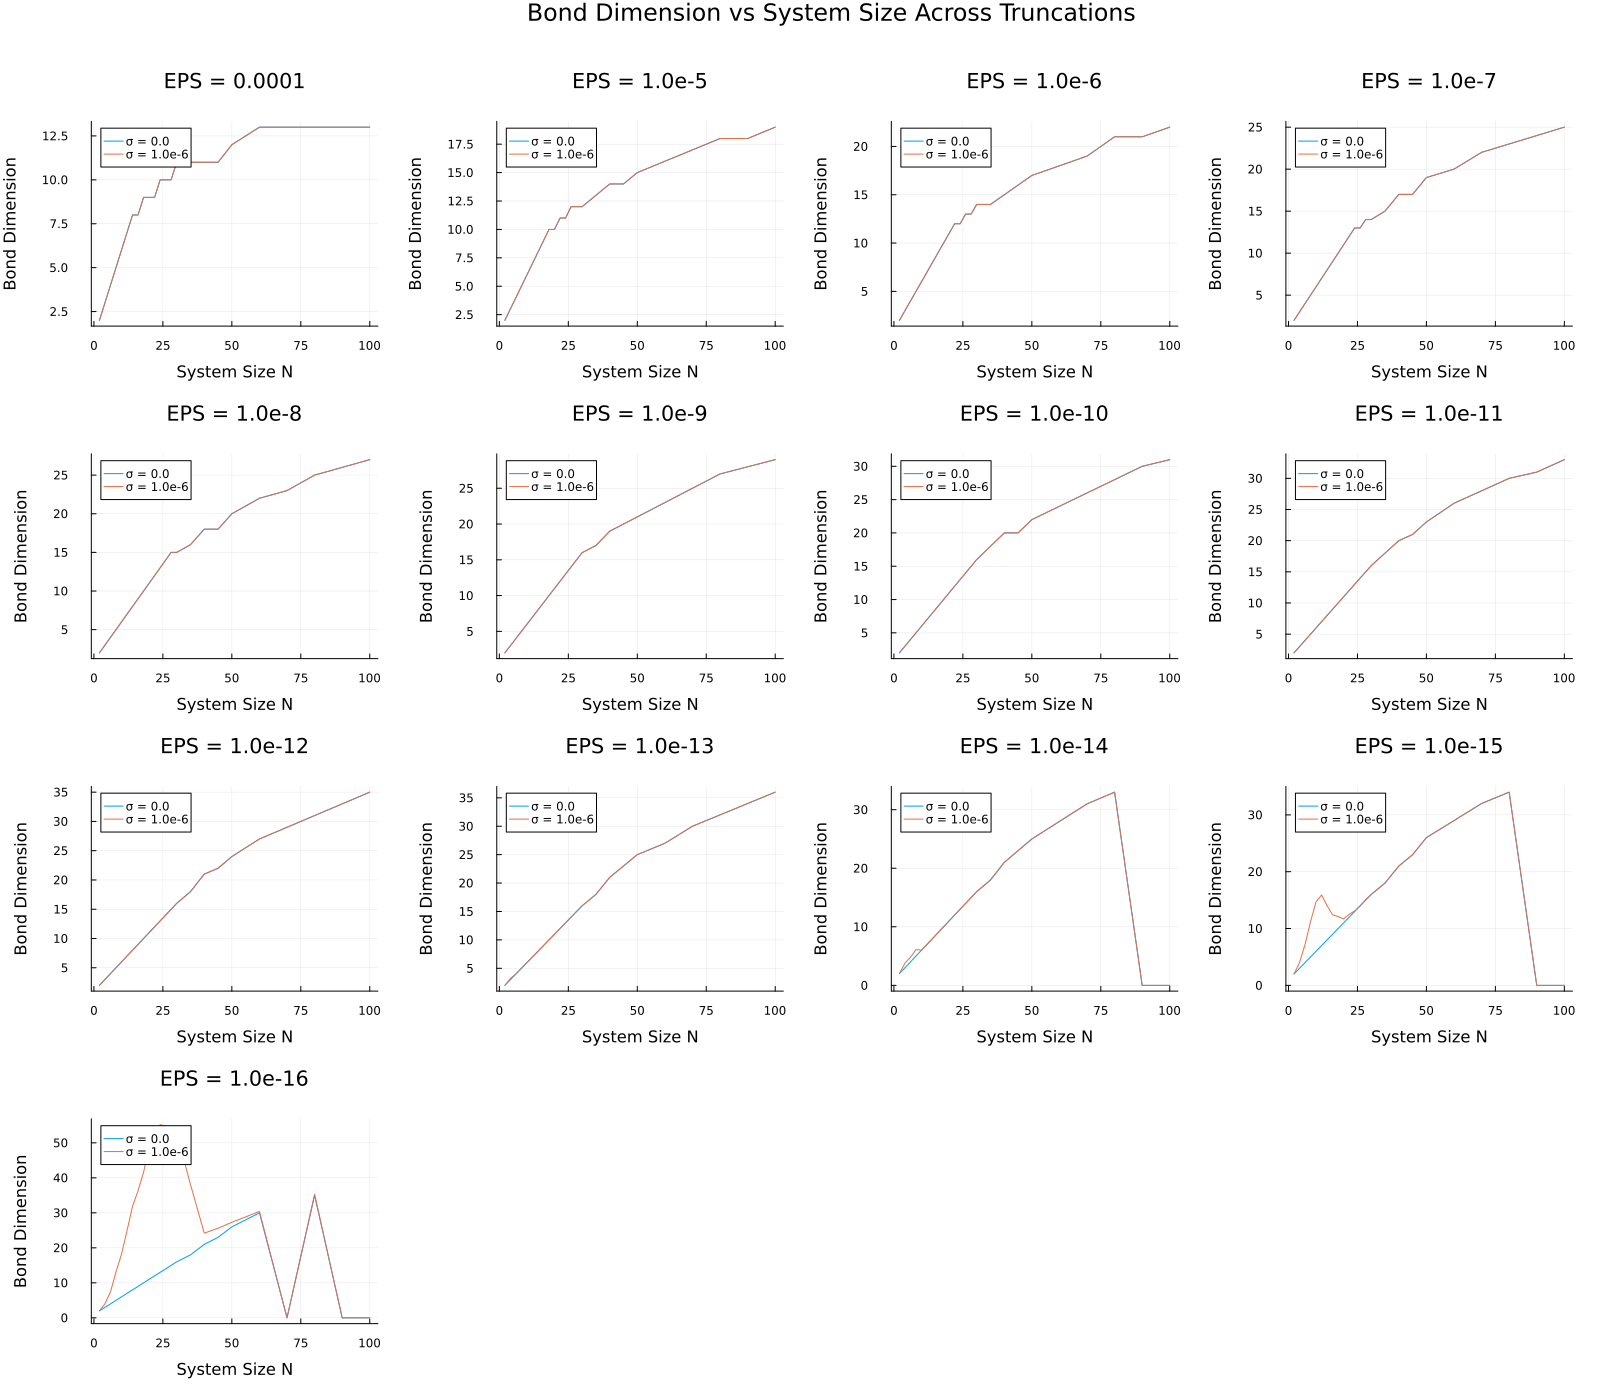

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Sigmas\\images\\bd_grid_sigmas.png"

In [ ]:

my_sigmas = [0.0, 1.0e-6] 
p_sigma = plot_bond_dimensions(data_dict, selected_sigmas=my_sigmas)
display(p_sigma)
savefig(p_sigma, joinpath("images_EPS", "bd_grid_sigmas.png"))

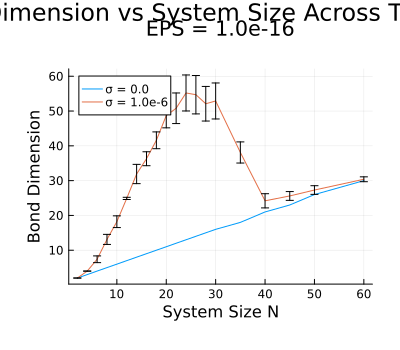

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Sigmas\\images\\bd_single_sigma.png"

In [ ]:
p_sigma_trunc = plot_bond_dimensions(
    data_dict, 
    selected_sigmas = [0.0, 1.0e-6], 
    selected_cutoffs = [1e-16],
    selected_N = [2:2:30; 35:5:50; 60],
    plot_errors = true
)
display(p_sigma_trunc)
savefig(p_sigma_trunc, joinpath("images_EPS", "bd_single_sigma.png"))

# Focusing only on the EPS data

In [100]:
function plot_bond_dimensions_EPS(data_dict, cutoff=1e-16; selected_sigmas=nothing, selected_N=nothing, plot_errors=false)
    if !haskey(data_dict, cutoff)
        @warn "Cutoff $cutoff not found in data_dict."
        return plot()
    end
    
    target_data  = data_dict[cutoff]
    avg_matrix   = target_data["avg_matrix"]
    err_matrix   = target_data["err_matrix"]
    N_range      = target_data["N_range"]
    sigma_values = target_data["sigma_values"]
    
    N_idx = if selected_N !== nothing
        findall(n -> n in selected_N, N_range)
    else
        1:length(N_range)
    end
    
    p = plot(
        title="Bond Dimension vs System Size (EPS = $cutoff)", 
        xlabel="System Size N", 
        ylabel="Bond Dimension",
        legend=:topleft,
        size=(700, 500),
        framestyle=:box,
        grid=true,
        margin=5Plots.mm
    )
    
    for (j, sig) in enumerate(sigma_values)
        if selected_sigmas !== nothing && !(sig in selected_sigmas)
            continue
        end
        
        if plot_errors && sig != 0.0
            plot!(p, N_range[N_idx], avg_matrix[N_idx, j], yerror=err_matrix[N_idx, j], label="σ = $sig", marker=:circle)
        else
            plot!(p, N_range[N_idx], avg_matrix[N_idx, j], label="σ = $sig", marker=:circle)
        end
    end
    
    return p
end

plot_bond_dimensions_EPS (generic function with 2 methods)

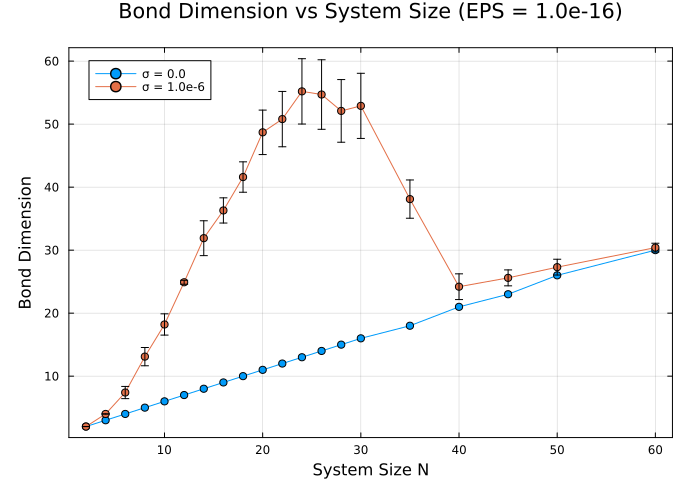

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Sigmas\\images\\bd_clean.png"

In [ ]:
p_EPS = plot_bond_dimensions_EPS(
    data_dict, 
    selected_sigmas = [0.0, 1e-6], 
    selected_N = [2:2:30; 35:5:50; 60],
    plot_errors = true
)
display(p_EPS)
savefig(p_EPS, joinpath("images_EPS", "bd_clean.png"))

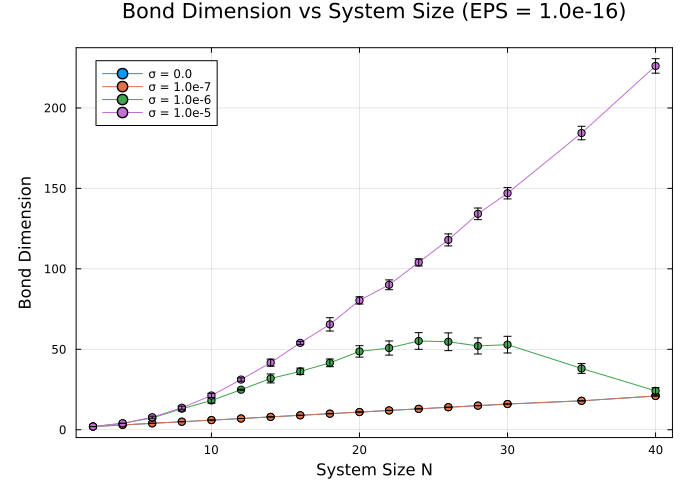

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Sigmas\\images\\bd_clean_sigmas.png"

In [ ]:
p_EPS = plot_bond_dimensions_EPS(
    data_dict, 
    selected_sigmas = [0.0, 1e-7, 1e-6, 1e-5], 
    selected_N = [2:2:30; 35; 40],
    plot_errors = true
)
display(p_EPS)
savefig(p_EPS, joinpath("images_EPS", "bd_clean_sigmas.png"))

# Schmidt spectrums

In [107]:
function plot_schmidt_spectra(data_dict, cutoff=1e-16; N_values=[10, 20, 30, 40], selected_sigmas=nothing, plot_errors=false)
    if !haskey(data_dict, cutoff)
        @warn "Cutoff $cutoff not found in data_dict."
        return plot()
    end
    
    target_data  = data_dict[cutoff]
    spectra_avg  = target_data["spectra_avg"]
    N_range      = target_data["N_range"]
    sigma_values = target_data["sigma_values"]
    
    plt_array = []
    
    for N in N_values
        N_idx = findfirst(==(N), N_range)
        
        if isnothing(N_idx)
            @warn "System size N=$N not found in N_range for cutoff $cutoff."
            push!(plt_array, plot(title="N = $N (Data Missing)", framestyle=:box))
            continue
        end
        
        p = plot(
            title="N = $N", 
            xlabel="Schmidt Index", 
            ylabel="Schmidt Value",
            yscale=:log10, 
            legend=:topright, 
            framestyle=:box,
            grid=true
        )
        
        for (j, sig) in enumerate(sigma_values)
            if selected_sigmas !== nothing && !(sig in selected_sigmas)
                continue
            end
            
            # Extract the 1D spectrum array for this specific N and sigma
            spectrum = spectra_avg[N_idx, j, :]
            
            # Filter out exact zeros
            filtered_spectrum = spectrum[spectrum .> 0]
            
            if !isempty(filtered_spectrum)
                # Order the spectrum strictly descending
                sorted_spectrum = sort(filtered_spectrum, rev=true)
                
                # Generate a new index range matching the sorted array's length
                x_vals = 1:length(sorted_spectrum)
                
                plot!(p, x_vals, sorted_spectrum, label="σ = $sig", marker=:circle)
            end
        end
        
        push!(plt_array, p)
    end
    
    n_plots = length(plt_array)
    cols = min(2, n_plots)
    rows = ceil(Int, n_plots / cols)
    
    final_plot = plot(
        plt_array..., 
        layout=(rows, cols), 
        size=(450 * cols, 350 * rows), 
        plot_title="Schmidt Spectra across System Sizes (EPS = $cutoff)",
        margin=6Plots.mm
    )
    
    return final_plot
end

plot_schmidt_spectra (generic function with 2 methods)

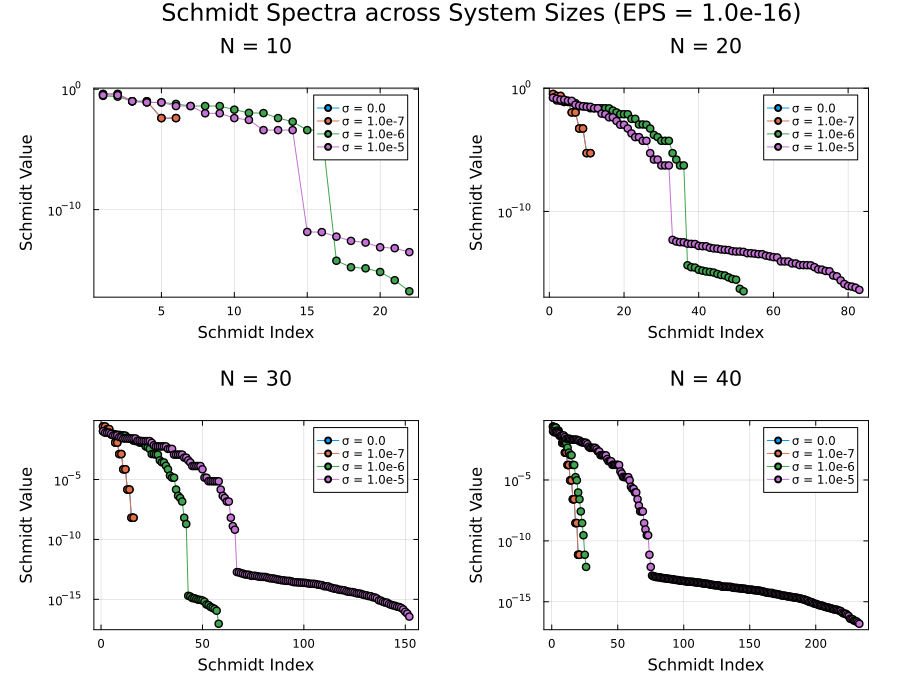

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Sigmas\\images\\ss_clean_sigmas.png"

In [ ]:
p_EPS = plot_schmidt_spectra(
    data_dict, 
    1e-16; 
    N_values=[10, 20, 30, 40], 
    selected_sigmas=[0.0, 1e-7, 1e-6, 1e-5]
)
display(p_EPS)
savefig(p_EPS, joinpath("images_EPS", "ss_clean_sigmas.png"))

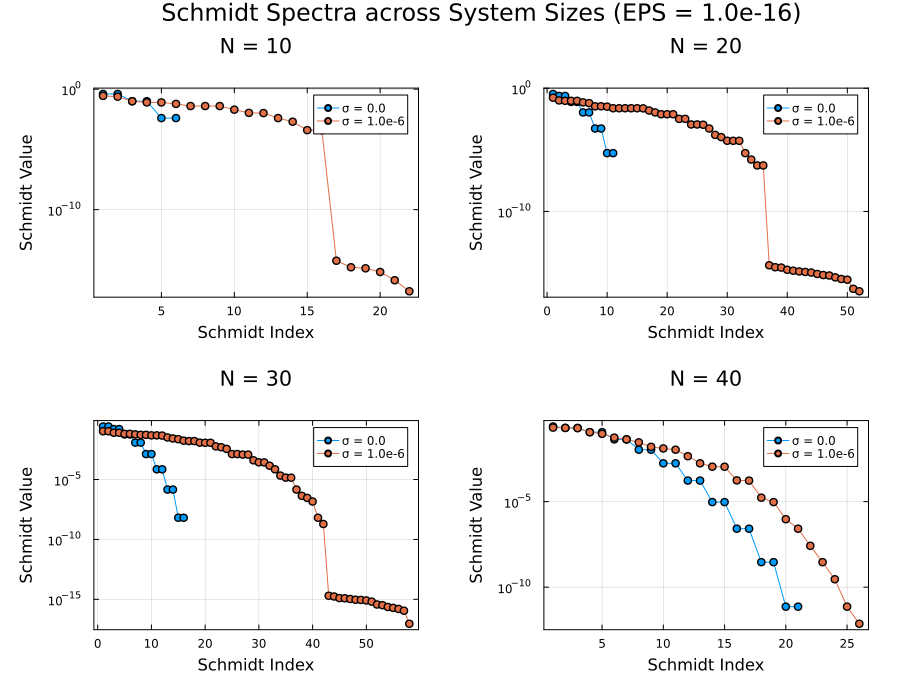

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Sigmas\\images\\ss_clean_clean.png"

In [ ]:
p_EPS = plot_schmidt_spectra(
    data_dict, 
    1e-16; 
    N_values=[10, 20, 30, 40], 
    selected_sigmas=[0.0, 1e-6]
)
display(p_EPS)
savefig(p_EPS, joinpath("images_EPS", "ss_clean_clean.png"))

# Entropies

In [114]:
function plot_renyi_entropy(data_dict, cutoff=1e-16; selected_sigmas=nothing, selected_N=nothing, alpha=1.0)
    if !haskey(data_dict, cutoff)
        @warn "Cutoff $cutoff not found in data_dict."
        return plot()
    end
    
    target_data  = data_dict[cutoff]
    spectra_avg  = target_data["spectra_avg"]
    N_range      = target_data["N_range"]
    sigma_values = target_data["sigma_values"]
    
    N_idx = if selected_N !== nothing
        findall(n -> n in selected_N, N_range)
    else
        1:length(N_range)
    end
    
    if isempty(N_idx)
        @warn "No valid N values found/selected to plot."
        return plot() 
    end
    
    p_plot = plot(
        title="Rényi Entropy (α = $alpha, EPS = $cutoff)", 
        xlabel="System Size N", 
        ylabel="S_$(alpha)",
        legend=:topleft,
        size=(700, 500),
        framestyle=:box,
        grid=true,
        margin=5Plots.mm
    )
    
    for (j, sig) in enumerate(sigma_values)
        if selected_sigmas !== nothing && !(sig in selected_sigmas)
            continue
        end
        
        entropies = Float64[]
        valid_N = Int[]
        
        for i in N_idx
            # Extract the probability spectrum
            p = spectra_avg[i, j, :]
            
            # Filter out zeros to avoid log(0) domain errors
            p_valid = p[p .> 0]
            
            if isempty(p_valid)
                continue
            end
            
            # Calculate Rényi Entropy based on the chosen alpha
            if isapprox(alpha, 1.0, atol=1e-5)
                # Shannon / von Neumann Entropy limit
                S = -sum(p_valid .* log.(p_valid))
            elseif isapprox(alpha, 0.0, atol=1e-5)
                # Max / Hartley Entropy limit
                S = log(length(p_valid))
            else
                # Standard Rényi Entropy formula
                S = (1.0 / (1.0 - alpha)) * log(sum(p_valid .^ alpha))
            end
            
            push!(entropies, S)
            push!(valid_N, N_range[i])
        end
        
        if !isempty(entropies)
            plot!(p_plot, valid_N, entropies, label="σ = $sig", marker=:circle)
        end
    end
    
    return p_plot
end



plot_renyi_entropy (generic function with 2 methods)

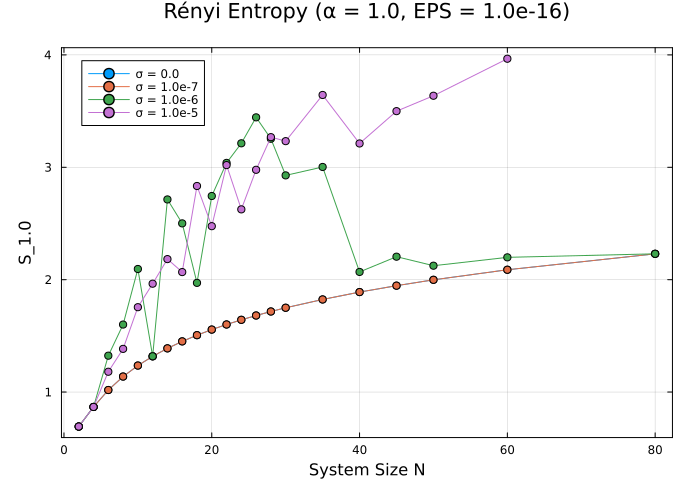

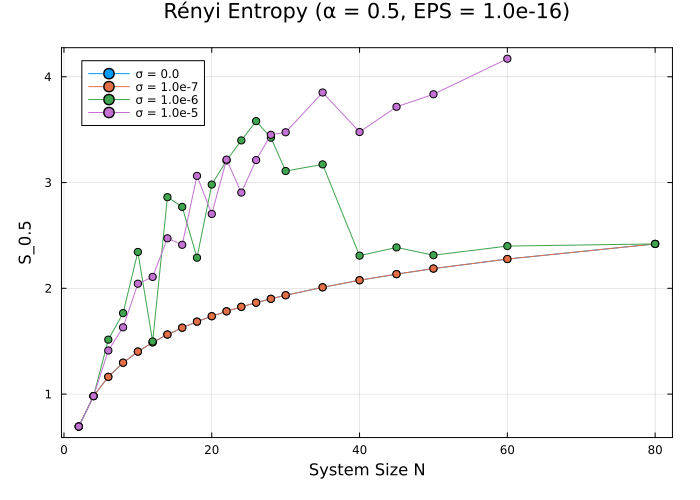

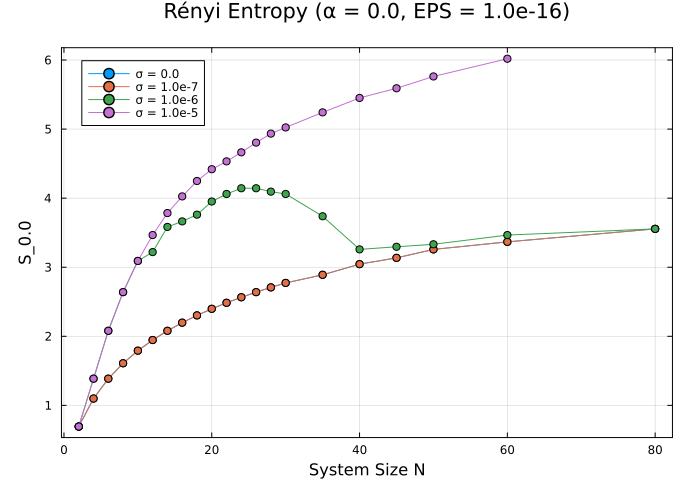

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Sigmas\\images\\ent_0.0.png"

In [ ]:


p_ent = plot_renyi_entropy(
    data_dict, 
    1e-16; 
    selected_sigmas=[0.0, 1e-7, 1e-6, 1e-5],  
    alpha=1.0
    )

display(p_ent)
savefig(p_ent, joinpath("images_EPS", "ent_1.0_sigmas.png"))

p_ent = plot_renyi_entropy(
    data_dict, 
    1e-16; 
    selected_sigmas=[0.0, 1e-7, 1e-6, 1e-5],  
    alpha=0.5
    )

display(p_ent)
savefig(p_ent, joinpath("images_EPS", "ent_0.5_sigmas.png"))

p_ent = plot_renyi_entropy(
    data_dict, 
    1e-16; 
    selected_sigmas=[0.0, 1e-7, 1e-6, 1e-5],  
    alpha=0.0
    )

display(p_ent)
savefig(p_ent, joinpath("images_EPS", "ent_0.0_sigmas.png"))



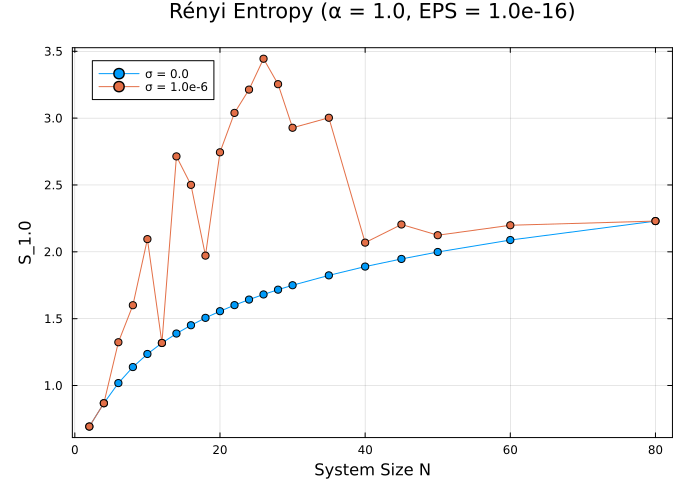

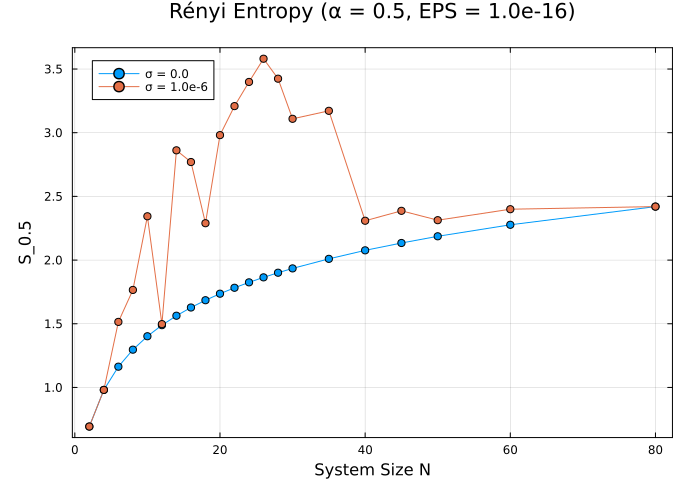

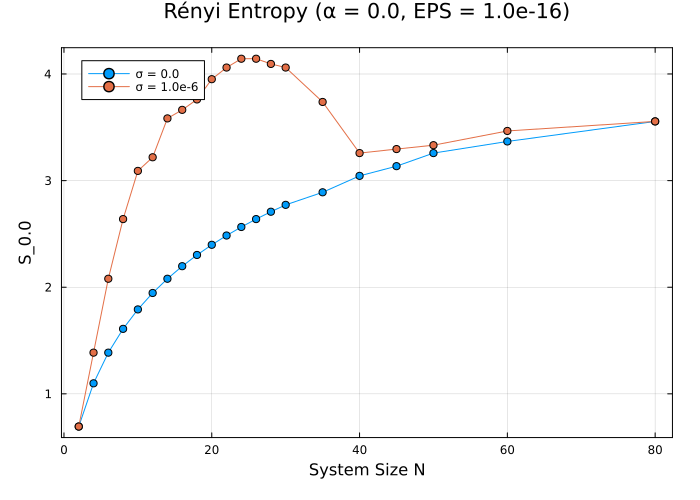

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Sigmas\\images\\ent_0.0.png"

In [ ]:


p_ent = plot_renyi_entropy(
    data_dict, 
    1e-16; 
    selected_sigmas=[0.0, 1e-6],  
    alpha=1.0
    )

display(p_ent)
savefig(p_ent, joinpath("images_EPS", "ent_1.0.png"))

p_ent = plot_renyi_entropy(
    data_dict, 
    1e-16; 
    selected_sigmas=[0.0, 1e-6],  
    alpha=0.5
    )

display(p_ent)
savefig(p_ent, joinpath("images_EPS", "ent_0.5.png"))

p_ent = plot_renyi_entropy(
    data_dict, 
    1e-16; 
    selected_sigmas=[0.0, 1e-6],  
    alpha=0.0
    )

display(p_ent)
savefig(p_ent, joinpath("images_EPS", "ent_0.0.png"))

